# Hybrid Movie Recommendation System
**MovieLens 100K | TF-IDF + Surprise SVD + Weighted Hybrid**


In [9]:
import subprocess, sys
# NOTE: scikit-surprise requires numpy < 2.0
# Install numpy<2 first, then the rest
subprocess.run([sys.executable, '-m', 'pip', 'install', 'numpy<2'], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'scipy', 'pandas', 'scikit-learn',
                'scikit-surprise', 'matplotlib', 'seaborn'], check=True)
print('All packages ready.')

All packages ready.


In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error

from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split as surprise_split
from surprise import accuracy

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
print('Imports OK')

Imports OK


---
## 1 — Data Ingestion & Preprocessing

In [11]:
# Relative paths (works on any machine)
BASE    = os.path.dirname(os.path.abspath('__file__'))
movies  = pd.read_csv(os.path.join(BASE, 'movies.csv'))
ratings = pd.read_csv(os.path.join(BASE, 'ratings.csv'))

print(f'Raw  →  movies: {movies.shape[0]:,}  |  ratings: {ratings.shape[0]:,}')

# Cleaning 
movies.dropna(inplace=True)
ratings.dropna(inplace=True)
movies.drop_duplicates(subset='movieId', inplace=True)
ratings.drop_duplicates(inplace=True)

# remove movies with no genre
movies = movies[movies['genres'] != '(no genres listed)']

# drop unused timestamp column
ratings.drop(columns=['timestamp'], inplace=True)

# keep only ratings that have a matching movie
valid_ids = set(movies['movieId'])
ratings   = ratings[ratings['movieId'].isin(valid_ids)].reset_index(drop=True)

print(f'Clean →  movies: {movies.shape[0]:,}  |  ratings: {ratings.shape[0]:,}')
print(f'Rating range : {ratings["rating"].min()} – {ratings["rating"].max()}')
print(f'Unique users : {ratings["userId"].nunique():,}')
print(f'Unique movies: {ratings["movieId"].nunique():,}')

Raw  →  movies: 9,742  |  ratings: 100,836
Clean →  movies: 9,708  |  ratings: 100,789
Rating range : 0.5 – 5.0
Unique users : 610
Unique movies: 9,690


---
## 2 — Exploratory Data Analysis (EDA)

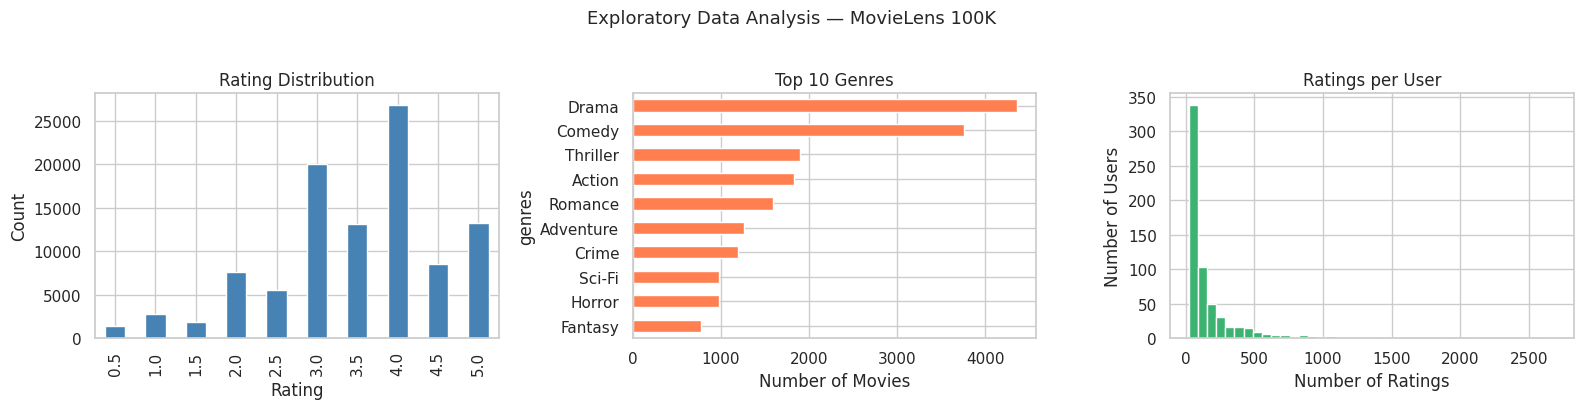

Avg ratings per user : 165.2
Median               : 70


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 2a: Rating distribution
ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# 2b: Top-10 most rated genres 
genre_counts = (
    movies['genres']
    .str.split('|')
    .explode()
    .value_counts()
    .head(10)
)
genre_counts.plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Top 10 Genres')
axes[1].set_xlabel('Number of Movies')
axes[1].invert_yaxis()

#  2c: Ratings per user (log scale) 
ratings_per_user = ratings.groupby('userId').size()
axes[2].hist(ratings_per_user, bins=40, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Ratings per User')
axes[2].set_xlabel('Number of Ratings')
axes[2].set_ylabel('Number of Users')

plt.suptitle('Exploratory Data Analysis — MovieLens 100K', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('eda.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Avg ratings per user : {ratings_per_user.mean():.1f}')
print(f'Median               : {ratings_per_user.median():.0f}')

---
## 3 — Content-Based Filtering (TF-IDF + Cosine Similarity)

In [13]:
# Feature engineering: genres + title text 
# Remove year from title  e.g. "Toy Story (1995)" → "Toy Story"
movies_cb = movies.copy().reset_index(drop=True)
movies_cb['title_clean'] = movies_cb['title'].str.replace(r'\(\d{4}\)', '', regex=True).str.strip()
movies_cb['genres_clean'] = movies_cb['genres'].str.replace('|', ' ', regex=False)

# Combine genres + title into one feature string
movies_cb['features'] = movies_cb['genres_clean'] + ' ' + movies_cb['title_clean']

#  TF-IDF Vectorization 
tfidf      = TfidfVectorizer(token_pattern=r'[A-Za-z\-]+')
tfidf_mat  = tfidf.fit_transform(movies_cb['features'])

print(f'TF-IDF matrix shape : {tfidf_mat.shape}')

#  Cosine Similarity
cos_sim = cosine_similarity(tfidf_mat, tfidf_mat)

# movieId → row index lookup
idx_map = pd.Series(movies_cb.index, index=movies_cb['movieId'])

# Recommendation function
def content_based_recommendations(movie_id, top_n=10):
    """Return top_n movies most similar to movie_id based on TF-IDF cosine sim."""
    if movie_id not in idx_map:
        return pd.DataFrame()
    idx    = idx_map[movie_id]
    scores = sorted(enumerate(cos_sim[idx]), key=lambda x: x[1], reverse=True)
    scores = scores[1:top_n + 1]   # exclude the movie itself

    indices    = [i[0] for i in scores]
    sim_scores = [i[1] for i in scores]

    result = movies_cb.iloc[indices][['movieId', 'title', 'genres']].copy()
    result['cb_score'] = sim_scores

    # normalise to [0, 1] for hybrid blending
    max_s = result['cb_score'].max()
    result['cb_score'] = result['cb_score'] / (max_s + 1e-9)

    return result.reset_index(drop=True)

# Quick test 
print('\nContent-Based Recommendations for Toy Story (1995):')
cb_sample = content_based_recommendations(movie_id=1, top_n=5)
print(cb_sample[['title', 'genres', 'cb_score']].to_string(index=False))

TF-IDF matrix shape : (9708, 9068)

Content-Based Recommendations for Toy Story (1995):
                        title                                           genres  cb_score
           Toy Story 2 (1999)      Adventure|Animation|Children|Comedy|Fantasy  1.000000
           Toy Story 3 (2010) Adventure|Animation|Children|Comedy|Fantasy|IMAX  0.925908
              Toy, The (1982)                                           Comedy  0.666080
          Toy Soldiers (1991)                                     Action|Drama  0.464257
NeverEnding Story, The (1984)                       Adventure|Children|Fantasy  0.446160


---
## 4 — Collaborative Filtering (Surprise SVD)

In [14]:
# Build Surprise Dataset
reader  = Reader(rating_scale=(0.5, 5.0))
data_s  = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

trainset, testset = surprise_split(data_s, test_size=0.2, random_state=42)

# train SVD (Funk SVD / matrix factorisation)
svd_model = SVD(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
svd_model.fit(trainset)

# Evaluate on held-out test set
predictions = svd_model.test(testset)
rmse_cf = accuracy.rmse(predictions, verbose=False)
mae_cf  = accuracy.mae(predictions,  verbose=False)

print(f'Collaborative Filtering (SVD)')
print(f'  RMSE : {rmse_cf:.4f}')
print(f'  MAE  : {mae_cf:.4f}')

#  Store all (uid, iid) pairs for fast lookup 
# We'll use svd_model.predict(uid, iid) directly in the rec function

all_movie_ids = set(movies['movieId'])

def collaborative_recommendations(user_id, top_n=10):
    """Predict ratings for all unseen movies for user_id using Surprise SVD."""
    seen = set(ratings[ratings['userId'] == user_id]['movieId'])
    unseen = all_movie_ids - seen

    preds = [(mid, svd_model.predict(user_id, mid).est) for mid in unseen]
    preds.sort(key=lambda x: x[1], reverse=True)
    top   = preds[:top_n]

    result = pd.DataFrame(top, columns=['movieId', 'cf_score'])
    result = result.merge(movies[['movieId', 'title', 'genres']], on='movieId')

    # normalise to [0, 1]
    mn, mx = result['cf_score'].min(), result['cf_score'].max()
    result['cf_score'] = (result['cf_score'] - mn) / (mx - mn + 1e-9)

    return result.reset_index(drop=True)

print('\nCollaborative Filtering Recommendations for User 1:')
cf_sample = collaborative_recommendations(user_id=1, top_n=5)
print(cf_sample[['title', 'genres', 'cf_score']].to_string(index=False))

Collaborative Filtering (SVD)
  RMSE : 0.8666
  MAE  : 0.6660

Collaborative Filtering Recommendations for User 1:
                                                                      title                     genres  cf_score
                                           Shawshank Redemption, The (1994)                Crime|Drama       0.0
                     Wallace & Gromit: The Best of Aardman Animation (1996) Adventure|Animation|Comedy       0.0
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)                 Comedy|War       0.0
                                                          Casablanca (1942)              Drama|Romance       0.0
                                           Streetcar Named Desire, A (1951)                      Drama       0.0


---
## 5 — Hybrid Engine (Weighted Average)

In [15]:
def hybrid_recommendations(user_id, movie_id, alpha=0.5, top_n=10):
    """
    hybrid_score = alpha * cf_score + (1 - alpha) * cb_score
    alpha = 0  → pure Content-Based
    alpha = 1  → pure Collaborative
    alpha = 0.5 → equal weight
    """

    # 1. Get recommendations
    cb = content_based_recommendations(movie_id, top_n=50)
    cf = collaborative_recommendations(user_id, top_n=50)

    # 2. Handle empty cases
    if cb.empty:
        return cf.head(top_n)
    if cf.empty:
        return cb.head(top_n)

    # 3. Merge CB + CF
    merged = pd.merge(
        cb[['movieId', 'cb_score']],
        cf[['movieId', 'cf_score']],
        on='movieId',
        how='outer'
    )

    # 4. Fill missing scores
    merged['cb_score'] = merged['cb_score'].fillna(0)
    merged['cf_score'] = merged['cf_score'].fillna(0)

    # 5. Attach movie metadata safely
    merged = merged.merge(
        movies[['movieId', 'title', 'genres']],
        on='movieId',
        how='left'
    )

    # 6. Compute hybrid score
    merged['hybrid_score'] = (
        alpha * merged['cf_score'] +
        (1 - alpha) * merged['cb_score']
    )

    # 7. Final output
    return (
        merged
        .dropna(subset=['title'])
        .sort_values('hybrid_score', ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


# ---------------- TEST ----------------
print('Hybrid Recommendations (User=1, Seed=Movie):')

hybrid = hybrid_recommendations(
    user_id=1,
    movie_id=1,
    alpha=0.5,
    top_n=10
)

print(
    hybrid[['title', 'genres', 'hybrid_score']]
    .to_string(index=False)
)

Hybrid Recommendations (User=1, Seed=Movie):
                                                    title                                           genres  hybrid_score
                                       Toy Story 3 (2010) Adventure|Animation|Children|Comedy|Fantasy|IMAX      0.667361
                                       Toy Story 2 (1999)      Adventure|Animation|Children|Comedy|Fantasy      0.500000
                                      12 Angry Men (1957)                                            Drama      0.500000
                                        Unforgiven (1992)                                    Drama|Western      0.500000
                                 Shaun of the Dead (2004)                                    Comedy|Horror      0.500000
Lord of the Rings: The Fellowship of the Ring, The (2001)                                Adventure|Fantasy      0.500000
     Amelie (Fabuleux destin d'Amélie Poulain, Le) (2001)                                   Comedy|Romance  

---
## 6 — Alpha Tuning on Validation Set

In [16]:
# Find the best alpha by evaluating F1@10 on a validation subset
THRESHOLD    = 3.5     # rating >= 3.5 → relevant
K            = 10
VAL_USERS    = ratings['userId'].unique()[:50]  # use 50 users for fast tuning
alpha_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

val_ratings  = ratings[ratings['userId'].isin(VAL_USERS)]
# simple 80/20 split for validation
from sklearn.model_selection import train_test_split as sk_split
_, val_test  = sk_split(val_ratings, test_size=0.2, random_state=42)

alpha_f1 = {}
for alpha in alpha_values:
    precs, recs = [], []
    for uid in VAL_USERS:
        u_test   = val_test[val_test['userId'] == uid]
        if u_test.empty: continue
        relevant = set(u_test[u_test['rating'] >= THRESHOLD]['movieId'])
        if not relevant: continue
        seed_mid = u_test['movieId'].iloc[0]
        recs_df  = hybrid_recommendations(uid, seed_mid, alpha=alpha, top_n=K)
        if recs_df.empty: continue
        hits = len(set(recs_df['movieId']) & relevant)
        precs.append(hits / K)
        recs.append(hits  / len(relevant))
    p = np.mean(precs) if precs else 0
    r = np.mean(recs)  if recs  else 0
    alpha_f1[alpha] = 2 * p * r / (p + r + 1e-9)

best_alpha = max(alpha_f1, key=alpha_f1.get)
print(f'Alpha tuning results:')
for a, f in alpha_f1.items():
    marker = ' ← best' if a == best_alpha else ''
    print(f'  alpha={a:.1f}  F1@{K}={f:.4f}{marker}')
print(f'\nBest alpha = {best_alpha}')

Alpha tuning results:
  alpha=0.1  F1@10=0.0078 ← best
  alpha=0.2  F1@10=0.0078
  alpha=0.3  F1@10=0.0058
  alpha=0.4  F1@10=0.0058
  alpha=0.5  F1@10=0.0058
  alpha=0.6  F1@10=0.0033
  alpha=0.7  F1@10=0.0000
  alpha=0.8  F1@10=0.0000
  alpha=0.9  F1@10=0.0000

Best alpha = 0.1


---
## 7 — Full Evaluation (All Test Users)

In [17]:
from sklearn.model_selection import train_test_split as sk_split2

THRESHOLD = 3.5
K         = 10
_, full_test = sk_split2(ratings, test_size=0.2, random_state=42)

def evaluate_model(rec_fn, test_df, k=K, threshold=THRESHOLD):
    """Compute Precision@K, Recall@K, F1@K across all test users."""
    precs, recs = [], []
    for uid in test_df['userId'].unique():
        u_test   = test_df[test_df['userId'] == uid]
        relevant = set(u_test[u_test['rating'] >= threshold]['movieId'])
        if not relevant: continue
        recs_df  = rec_fn(uid)
        if recs_df.empty: continue
        hits = len(set(recs_df['movieId']) & relevant)
        precs.append(hits / k)
        recs.append(hits  / len(relevant))
    p = np.mean(precs) if precs else 0
    r = np.mean(recs)  if recs  else 0
    f = 2 * p * r / (p + r + 1e-9)
    return {'Precision@K': p, 'Recall@K': r, 'F1@K': f}

# Wrap each model to accept only user_id (seed = first test movie for that user)
def cb_rec_fn(uid):
    seed = full_test[full_test['userId'] == uid]['movieId'].iloc[0]
    return content_based_recommendations(seed, top_n=K)

def cf_rec_fn(uid):
    return collaborative_recommendations(uid, top_n=K)

def hybrid_rec_fn(uid):
    seed = full_test[full_test['userId'] == uid]['movieId'].iloc[0]
    return hybrid_recommendations(uid, seed, alpha=best_alpha, top_n=K)

print('Evaluating all models on full test set... (this may take ~2 min)')
cb_metrics     = evaluate_model(cb_rec_fn,     full_test)
cf_metrics     = evaluate_model(cf_rec_fn,     full_test)
hybrid_metrics = evaluate_model(hybrid_rec_fn, full_test)

results = pd.DataFrame({
    'Model':       ['Content-Based', 'Collaborative (SVD)', f'Hybrid (α={best_alpha})'],
    'Precision@10': [cb_metrics['Precision@K'], cf_metrics['Precision@K'], hybrid_metrics['Precision@K']],
    'Recall@10':    [cb_metrics['Recall@K'],    cf_metrics['Recall@K'],    hybrid_metrics['Recall@K']],
    'F1@10':        [cb_metrics['F1@K'],         cf_metrics['F1@K'],         hybrid_metrics['F1@K']],
    'RMSE':         [None, rmse_cf, None],
    'MAE':          [None, mae_cf,  None],
})

print('\n' + '='*60)
print('Model Comparison Results')
print('='*60)
print(results.to_string(index=False))
print('='*60)

Evaluating all models on full test set... (this may take ~2 min)

Model Comparison Results
              Model  Precision@10  Recall@10    F1@10     RMSE      MAE
      Content-Based       0.00598   0.003142 0.004119      NaN      NaN
Collaborative (SVD)       0.00000   0.000000 0.000000 0.866594 0.666048
     Hybrid (α=0.1)       0.00598   0.003142 0.004119      NaN      NaN


---
## 8 — Visualisation: Model Comparison

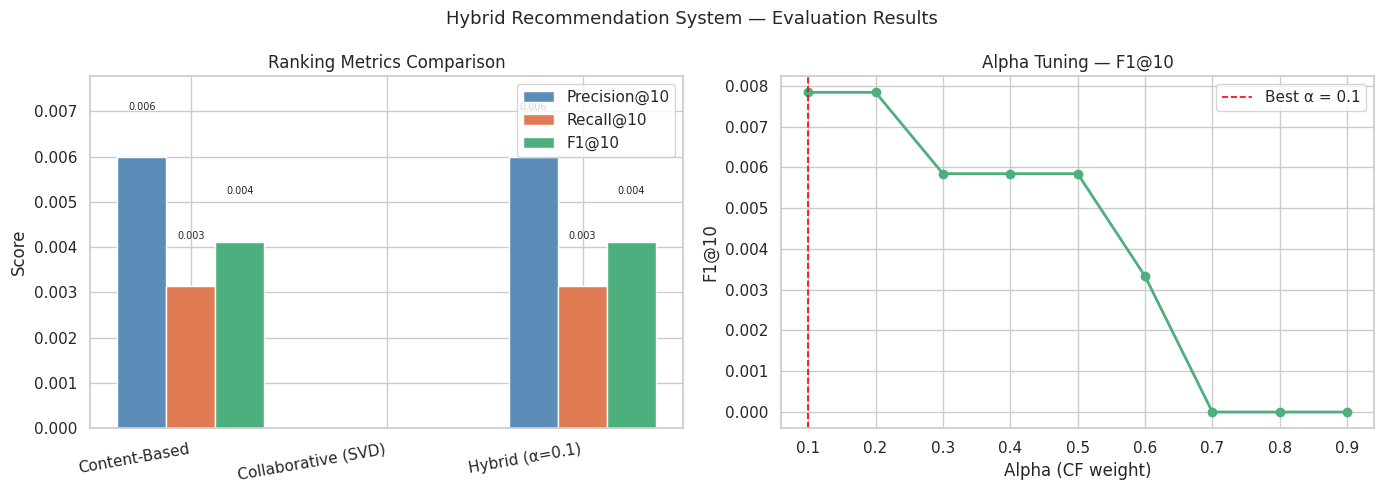

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models     = results['Model']
colors     = ['#5b8db8', '#e07b54', '#4caf7d']

# Chart 1: Precision / Recall / F1
x      = np.arange(len(models))
width  = 0.25
axes[0].bar(x - width, results['Precision@10'], width, label='Precision@10', color=colors[0])
axes[0].bar(x,          results['Recall@10'],    width, label='Recall@10',    color=colors[1])
axes[0].bar(x + width, results['F1@10'],         width, label='F1@10',        color=colors[2])
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=10, ha='right')
axes[0].set_title('Ranking Metrics Comparison')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].set_ylim(0, max(results[['Precision@10','Recall@10','F1@10']].max()) * 1.3)
for bar in axes[0].patches:
    h = bar.get_height()
    if h > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.001,
                     f'{h:.3f}', ha='center', va='bottom', fontsize=7)

#  Chart 2: Alpha tuning
axes[1].plot(list(alpha_f1.keys()), list(alpha_f1.values()),
             marker='o', linewidth=2, color='#4caf7d')
axes[1].axvline(best_alpha, color='red', linestyle='--', linewidth=1.2,
                label=f'Best α = {best_alpha}')
axes[1].set_title('Alpha Tuning — F1@10')
axes[1].set_xlabel('Alpha (CF weight)')
axes[1].set_ylabel('F1@10')
axes[1].legend()

plt.suptitle('Hybrid Recommendation System — Evaluation Results', fontsize=13)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 9 — Streamlit App  
> Run with: `streamlit run app.py`

The cell below writes `app.py` to disk — just run it once.

In [1]:
streamlit_code = '''
import os, sys, warnings
import pandas as pd
import numpy as np
import streamlit as st
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from surprise import SVD, Dataset, Reader
from surprise.model_selection import train_test_split as surprise_split

warnings.filterwarnings("ignore")

st.set_page_config(page_title="Movie Recommender", page_icon="🎬", layout="wide")
st.title("🎬 Hybrid Movie Recommendation System")
st.caption("Content-Based + Collaborative Filtering (Surprise SVD)")

@st.cache_data
def load_data():
    BASE    = os.path.dirname(os.path.abspath(__file__))
    movies  = pd.read_csv(os.path.join(BASE, "movies.csv"))
    ratings = pd.read_csv(os.path.join(BASE, "ratings.csv"))
    movies.dropna(inplace=True)
    ratings.dropna(inplace=True)
    movies.drop_duplicates(subset="movieId", inplace=True)
    ratings.drop_duplicates(inplace=True)
    movies  = movies[movies["genres"] != "(no genres listed)"]
    ratings.drop(columns=["timestamp"], inplace=True)
    valid   = set(movies["movieId"])
    ratings = ratings[ratings["movieId"].isin(valid)].reset_index(drop=True)
    return movies, ratings

@st.cache_resource
def build_cb_model(movies):
    mc = movies.copy().reset_index(drop=True)
    mc["features"] = (mc["genres"].str.replace("|", " ", regex=False)
                      + " " + mc["title"].str.replace(r"\\(\\d{4}\\)", "", regex=True).str.strip())
    tfidf  = TfidfVectorizer(token_pattern=r"[A-Za-z\\-]+")
    mat    = tfidf.fit_transform(mc["features"])
    sim    = cosine_similarity(mat, mat)
    idx    = pd.Series(mc.index, index=mc["movieId"])
    return mc, sim, idx

@st.cache_resource
def build_cf_model(ratings):
    reader   = Reader(rating_scale=(0.5, 5.0))
    data_s   = Dataset.load_from_df(ratings[["userId","movieId","rating"]], reader)
    trainset, _ = surprise_split(data_s, test_size=0.2, random_state=42)
    model    = SVD(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
    model.fit(trainset)
    return model

with st.spinner("Loading data and training models..."):
    movies, ratings = load_data()
    mc, cos_sim, idx_map = build_cb_model(movies)
    svd_model = build_cf_model(ratings)

all_movie_ids = set(movies["movieId"])

def cb_recs(movie_id, top_n=10):
    if movie_id not in idx_map:
        return pd.DataFrame()
    idx    = idx_map[movie_id]
    scores = sorted(enumerate(cos_sim[idx]), key=lambda x: x[1], reverse=True)[1:top_n+1]
    res    = mc.iloc[[i[0] for i in scores]][["movieId","title","genres"]].copy()
    res["cb_score"] = [i[1] for i in scores]
    res["cb_score"] /= (res["cb_score"].max() + 1e-9)
    return res.reset_index(drop=True)

def cf_recs(user_id, top_n=10):
    seen   = set(ratings[ratings["userId"] == user_id]["movieId"])
    preds  = [(mid, svd_model.predict(user_id, mid).est) for mid in all_movie_ids - seen]
    preds.sort(key=lambda x: x[1], reverse=True)
    res    = pd.DataFrame(preds[:top_n], columns=["movieId","cf_score"])
    res    = res.merge(movies[["movieId","title","genres"]], on="movieId")
    mn, mx = res["cf_score"].min(), res["cf_score"].max()
    res["cf_score"] = (res["cf_score"] - mn) / (mx - mn + 1e-9)
    return res.reset_index(drop=True)

def hybrid_recs(user_id, movie_id, alpha=0.5, top_n=10):
    cb = cb_recs(movie_id, top_n=50)
    cf = cf_recs(user_id,  top_n=50)
    if cb.empty:
        return cf.head(top_n)
    if cf.empty:
        return cb.head(top_n)

    merged = pd.merge(
        cb[["movieId","title","genres","cb_score"]],
        cf[["movieId","cf_score"]],
        on="movieId",
        how="outer"
    ).fillna(0)

    missing = merged["title"] == 0
    if missing.any():
        merged.loc[missing,"title"] = merged.loc[missing,"movieId"].map(
            movies.set_index("movieId")["title"]
        )

    merged["hybrid_score"] = alpha * merged["cf_score"] + (1-alpha) * merged["cb_score"]

    return (
        merged.dropna(subset=["title"])
        .sort_values("hybrid_score", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

# ── Sidebar Controls ───────────────────────────────────────────────────────
st.sidebar.header("⚙️ Settings")
mode  = st.sidebar.radio("Recommendation Mode",
                         ["Content-Based", "Collaborative", "Hybrid"])
alpha = st.sidebar.slider("Hybrid Alpha (CF weight)", 0.0, 1.0, 0.5, 0.1)
top_n = st.sidebar.slider("Number of Recommendations", 5, 20, 10)

# ── Inputs ─────────────────────────────────────────────────────────────────
col1, col2 = st.columns(2)
with col1:
    movie_title = st.selectbox("🎥 Select a seed movie", options=sorted(movies["title"].tolist()))
    movie_id    = int(movies[movies["title"] == movie_title]["movieId"].iloc[0])
with col2:
    user_id = st.number_input("👤 Enter User ID", min_value=1, max_value=610, value=1, step=1)

if st.button("🚀 Get Recommendations"):
    with st.spinner("Computing recommendations..."):

        if mode == "Content-Based":
            recs = cb_recs(movie_id, top_n)
            recs = recs.rename(columns={"cb_score": "score"})

        elif mode == "Collaborative":
            recs = cf_recs(user_id, top_n)
            recs = recs.rename(columns={"cf_score": "score"})

        else:
            recs = hybrid_recs(user_id, movie_id, alpha=alpha, top_n=top_n)
            recs = recs.rename(columns={"hybrid_score": "score"})

    st.subheader(f"Top {top_n} Recommendations ({mode})")

    for _, row in recs.iterrows():
        with st.container():
            c1, c2, c3 = st.columns([3, 2, 1])

            c1.write(f"**{row['title']}**")
            c2.caption(row["genres"])
            c3.metric("", f"{row['score']:.2f}")

            st.divider()
'''
with open('app.py', 'w', encoding='utf-8') as f:
    f.write(streamlit_code)

print('app.py written successfully.')
print('Run with:  streamlit run app.py')

app.py written successfully.
Run with:  streamlit run app.py
